In [1]:
import torch
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
import torch.nn as nn
from transformers import AutoModel

class XLMRClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            "xlm-roberta-base"
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            768,
            2
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state.mean(dim=1)

        x = self.dropout(cls_embedding)

        logits = self.fc(x)

        return logits

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = XLMRClassifier()

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MultilingualFakeNews/models/best_xlmr.pt",
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [6]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/MultilingualFakeNews/data/english_clean_v2.csv"
)

df = df[["text", "target"]]

In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["target"]
)

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [9]:
import torch
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_len=384
    ):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids":
                encoding["input_ids"].flatten(),

            "attention_mask":
                encoding["attention_mask"].flatten(),

            "label":
                torch.tensor(
                    self.labels[idx],
                    dtype=torch.long
                )
        }

In [10]:
val_dataset = FakeNewsDataset(
    val_df["text"].tolist(),
    val_df["target"].tolist(),
    tokenizer
)

In [11]:
from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [12]:
print(len(val_loader))

15


In [13]:
# Generate predictions

y_true = []
y_pred = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch["label"].to(device)

        outputs = model(
            input_ids,
            attention_mask
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

In [14]:
# Calculate Metrics
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8389830508474576
Precision: 0.8679245283018868
Recall   : 0.7931034482758621
F1 Score : 0.8288288288288288


In [15]:
# Detailed classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Legit",
            "Fake"
        ]
    )
)

              precision    recall  f1-score   support

       Legit       0.82      0.88      0.85        60
        Fake       0.87      0.79      0.83        58

    accuracy                           0.84       118
   macro avg       0.84      0.84      0.84       118
weighted avg       0.84      0.84      0.84       118



In [16]:
# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[53  7]
 [12 46]]


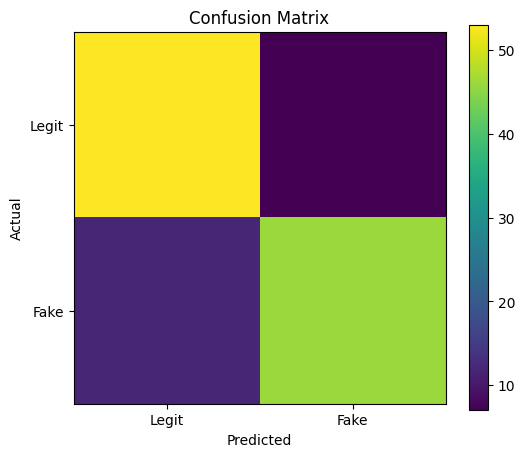

In [17]:
# Visualize Confusion Matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0,1],
    ["Legit","Fake"]
)

plt.yticks(
    [0,1],
    ["Legit","Fake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()